In [1]:
%pip install -qU langchain langchain-google-genai langchain_community tavily-python aiosqlite langchain-tavily 
%pip install -qU langgraph-checkpoint-sqlite 
%pip install -qU langgraph langgraph-checkpoint-sqlite
%pip install -qU langgraph 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
import sqlite3 
from langgraph.checkpoint.sqlite import SqliteSaver 
conn = sqlite3.connect("checkpoints.db", check_same_thread=False) 
memory = SqliteSaver(conn)

In [3]:
import google.generativeai as genai
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY') 
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

c:\Users\machi\Desktop\tech_ai_builder\temp\MULTIAGENTES_LANGGRAPH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\machi\AppData\Local\Temp\ipykernel_35412\393494481.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [4]:
from typing import TypedDict, List

class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

In [7]:
PLAN_PROMPT = """Eres un escritor especialista con la tarea de crear un esquema de alto nivel para una redacción. \
Escribe este esquema para el tema proporcionado por el usuario. Presenta un plan de la redacción junto con cualesquiera notas \
o instrucciones relevantes para las secciones."""

In [8]:
WRITER_PROMPT = """Eres un asistente de redacción con la tarea de escribir excelentes redacciones de 5 párrafos. \
Genera la mejor redacción posible para la solicitud del usuario y el esquema inicial. \
Si el usuario proporciona críticas, responde con una versión revisada de tus intentos anteriores. \
Utiliza toda la información a continuación según sea necesario:

------

{content}"""

In [9]:
REFLECTION_PROMPT = """Eres un profesor corrigiendo una redacción presentada. \
Genera una crítica y recomendaciones para la entrega del usuario. \
Proporciona recomendaciones detalladas, incluyendo solicitudes sobre extensión, profundidad, estilo, etc."""

In [10]:
RESEARCH_PLAN_PROMPT = """Eres un investigador encargado de proporcionar información que puede \
ser utilizada al escribir la siguiente redacción. Genera una lista de consultas de investigación que \
recopilen cualquier información relevante. Genera como máximo 3 consultas."""

In [11]:
RESEARCH_CRITIQUE_PROMPT = """Eres un investigador encargado de proporcionar información que puede \
ser utilizada al realizar cualquier revisión solicitada (según se describe a continuación). \
Genera una lista de consultas de investigación que recopilen cualquier información relevante. Genera como máximo 3 consultas."""

In [12]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [13]:
import os
from tavily import TavilyClient

tavily = TavilyClient(api_key=TAVILY_API_KEY)

In [14]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [15]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [16]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }

In [17]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [18]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [19]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [20]:
builder = StateGraph(AgentState)

In [21]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [22]:
builder.set_entry_point("planner")

In [23]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)

In [24]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")
builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [25]:
graph = builder.compile(checkpointer=memory)


--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---


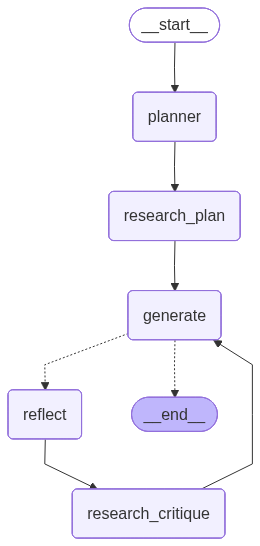

Grafo PNG generado y exhibido con éxito!


In [26]:
from IPython.display import Image, display, Markdown
import os

print("\n--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---")
try:

    image_data = graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
    print("Grafo PNG generado y exhibido con éxito!")

except Exception as e:

    print(f"\nError al tratar de generar el PNG del grafo: {e}")
    print("Esto posiblemente se debe a que:")
    print("1. El método `.draw_mermaid_png()` no existe en su versión de LangGraph.")
    print("2. Faltan dependencias como 'playwright' o sus drivers no fueron instalados.")
    print("   Trata con: pip install playwright && playwright install")
    print("3. Otro error inesperado al acceder al grafo o renderizar.")

    print("\n--- Tratando generar únicamente el código Mermaid (Fallback) ---")
    try:

        mermaid_code = graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid Generado (Pégalo en https://mermaid.live/ o utiliza Markdown en tu notebook) ---")
        print(mermaid_code)

    except Exception as e_mermaid:
        print(f"Error al generar el código Mermaid: {e_mermaid}")
        print("Verifica si 'graph.get_graph()' está correcto y es accesible.")

In [27]:
thread = {"configurable": {"thread_id": "5"}}
for s in graph.stream({
    'task': "Cuál es la diferencia entre LangChain y LangSmith",
    "max_revisions": 2,
    "revision_number": 1,
    "content": [], 
}, thread):
    print(s)

{'planner': {'plan': [{'type': 'text', 'text': 'Para redactar un artículo técnico claro y estructurado sobre la diferencia entre **LangChain** y **LangSmith**, te propongo el siguiente esquema de alto nivel. Este plan está diseñado para guiar al lector desde la conceptualización básica hasta la aplicación práctica en el ciclo de vida de una aplicación de IA.\n\n---\n\n### Título sugerido: *El ecosistema de la IA Generativa: Entendiendo la relación entre LangChain y LangSmith*\n\n#### I. Introducción\n*   **Contexto:** Breve mención sobre el auge de los LLMs (Large Language Models) y la complejidad de construir aplicaciones sobre ellos.\n*   **Definición rápida:** Presentar a LangChain como el "motor de construcción" y a LangSmith como el "taller de diagnóstico y optimización".\n*   **Tesis:** Aunque ambos pertenecen al mismo ecosistema, cumplen roles complementarios: uno facilita el desarrollo y el otro garantiza la calidad y observabilidad.\n\n#### II. LangChain: El Framework de Desar